<a href="https://colab.research.google.com/github/OscarRojasG/CLP-Framework/blob/main/CLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generador de instancias

Cada instancia se representa con el siguiente formato:

```
1                   # ID de la instancia
587 233 220         # Dimensiones del contenedor (L W H)
10                  # Número de tipos de cajas
1 108 0 76 0 30 1 20
2 110 0 43 1 25 1 11
3 92 1 81 1 55 1 9
4 81 0 33 1 28 1 9
5 120 1 99 1 73 1 9
6 111 0 70 1 48 1 13
7 98 0 72 1 46 1 4
8 95 0 66 0 31 1 12
9 85 0 84 0 30 1 9
10 71 0 32 1 25 1 10
```

Cada tipo de caja se describe en una línea con el siguiente formato:

```
id_caja  L  rotX  W  rotY  H  rotZ  cantidad
1 108 0 76 0 30 1 20
```

Donde:

* $L, W, H$ son las dimensiones de la caja
* $rotX, rotY, rotZ$ es la factibilidad de que cada caja pueda ser rotada sobre los ejes X, Y, Z.

In [ ]:
from typing import List
import random

class BoxType:
    def __init__(self, box_id, dims, rots, qty):
        self.id = box_id        # identificador de la caja
        self.dims = dims        # (L, W, H)
        self.rots = rots        # (rotX, rotY, rotZ)
        self.qty = qty          # cantidad de cajas


class CLPInstance:
    def __init__(self, container, boxes : list[BoxType]):
        self.container = container  # (L, W, H)
        self.n_types = len(boxes)
        self.boxes = boxes          # lista de BoxType


def instance(n_types=10, seed=None):
    """
    Genera una sola instancia del CLP como objeto CLPInstance.
    """
    if seed is not None:
        random.seed(seed)

    # Dimensiones del contenedor (fijas en este caso)
    l, w, h = 587, 233, 220

    # Límites de dimensiones de las cajas
    alpha = [30, 25, 20]   # mínimo largo, ancho, alto
    beta  = [120, 100, 80] # máximo largo, ancho, alto
    L = 2  # constante de estabilidad

    # Volumen del contenedor
    tc = l * w * h

    dimension_box = []
    cantidad_box_type = []
    volumen_box_type = []
    orientacion_box = []

    # Genera tipos de cajas
    for i in range(n_types):
        # Dimensiones aleatorias dentro de los rangos
        r_j = [random.randint(alpha[j], beta[j]) for j in range(3)]
        aux_dim = [alpha[j] + (r_j[j] % (beta[j] - alpha[j] + 1)) for j in range(3)]
        dimension_box.append(aux_dim)

        # Inicializa cantidad
        cantidad_box_type.append(1)

        # Volumen de la caja
        volumen_box_type.append(aux_dim[0] * aux_dim[1] * aux_dim[2])

        # Orientación factible según la constante L
        min_dim = min(aux_dim)
        aux_orient = [1 if aux_dim[j] / min_dim < L else 0 for j in range(3)]
        orientacion_box.append(aux_orient)

    # Rellena hasta que no quepa más
    volumen_cargo = 0
    while True:
        volumen_cargo = sum(cantidad_box_type[i] * volumen_box_type[i] for i in range(n_types))
        aux = random.randint(0, n_types - 1)
        v_k = volumen_box_type[aux]
        if tc > volumen_cargo + v_k:
            cantidad_box_type[aux] += 1
        else:
            break

    # Construye lista de BoxType
    boxes = [
        BoxType(i + 1, dimension_box[i], orientacion_box[i], cantidad_box_type[i])
        for i in range(n_types)
    ]

    return CLPInstance(container=(l, w, h), boxes=boxes)


def gen_instances(filename, n_instances=100, n_types=10, seed=None, offset=0):
    """
    Genera un archivo con varias instancias CLP en el formato definido.
    """
    with open(filename, "w") as f:
        # número total de instancias
        f.write(str(n_instances) + "\n")

        for inst_id in range(1 + offset, n_instances + 1 + offset):
            inst = instance(n_types=n_types, seed=(seed + inst_id) if seed is not None else None)

            # encabezado de la instancia
            f.write(f"{inst_id}\n")
            l, w, h = inst.container
            f.write(f"{l} {w} {h}\n")
            f.write(f"{inst.n_types}\n")

            # tipos de cajas
            for i, box in enumerate(inst.boxes):
                Lc, Wc, Hc = box.dims
                rotX, rotY, rotZ = box.rots
                qty = box.qty

                if inst_id == n_instances and i == len(inst.boxes) - 1:
                    f.write(f"{box.id} {Lc} {rotX} {Wc} {rotY} {Hc} {rotZ} {qty}")
                else:
                    f.write(f"{box.id} {Lc} {rotX} {Wc} {rotY} {Hc} {rotZ} {qty}\n")

def read_instances(filename) -> list[CLPInstance]:
    """
    Lee un archivo de instancias CLP y devuelve una lista de objetos CLPInstance.
    """
    instances = []
    with open(filename, "r") as f:
        # número total de instancias
        n_instances = int(f.readline().strip())

        for _ in range(n_instances):
            inst_id = int(f.readline().split()[0])  # id de la instancia

            # dimensiones del contenedor
            l, w, h = map(int, f.readline().split())

            # número de tipos de cajas
            n_types = int(f.readline().strip())

            boxes = []
            for _ in range(n_types):
                parts = f.readline().split()
                box_id = int(parts[0])
                Lc = int(parts[1])
                rotX = int(parts[2])
                Wc = int(parts[3])
                rotY = int(parts[4])
                Hc = int(parts[5])
                rotZ = int(parts[6])
                qty = int(parts[7])

                boxes.append(BoxType(box_id, (Lc, Wc, Hc), (rotX, rotY, rotZ), qty))

            instances.append(CLPInstance(container=(l, w, h), boxes=boxes))

    return instances

In [ ]:
gen_instances("prueba.txt", n_instances=5, n_types=10, seed=1)
read_instances("prueba.txt")

# BSG-VCS

Al ejecutar

```
./BSG_CLP prueba.txt -i 1 -t 10 --verbose2=5 > output.txt
```

se guardarán los bloques seleccionados por BSG para construir la solución, en conjunto con los $m=5$ bloques más prometedores para cada estado:

```
selected block:686 space:(362,0,103)
  action block:686 eval: 752760 0.024314749 0.85935438 0.16666667 279914.38
  action block:600 eval: 752760 0.1954876 0.76418638 0.16666667 144329.86
  action block:147 eval: 376380 0.024314749 0.79643276 0.33333333 118606.5
  action block:149 eval: 501840 0.024314749 0.73896542 0.25 110652.05
  action block:123 eval: 501840 0.11661384 0.74613438 0.25 104129.09
```

Los valores a continuación de `eval` indican las métricas:

```
eval: V Loss CS 1/n VCS
```

Nótese que en algunos casos, el bloque elegido por BSG no está dentro de los $m$ más prometedores. Estos casos son de particular relevancia ya que la heurística "falla" en su evaluación. En estos casos se imprime un sexto bloque:

```
selected block:141 space:(282,169,113)
  action block:2318 eval: 825600 0.068243858 0.68818263 0.2 125052.61
  action block:550 eval: 495360 0.041233657 0.66613802 0.33333333 75069.99
  action block:553 eval: 660480 0.055983909 0.60071472 0.25 61531.879
  action block:568 eval: 660480 0.26440305 0.61178143 0.25 51578.982
  action block:17 eval: 194532 0.007518797 0.70680679 1 48185.48
  action block:141 eval: 330240 0.01910828 0.62544895 0.5 43153.121
```


In [ ]:
%cd /content
!chmod +x BSG_CLP
!./BSG_CLP prueba.txt -i 1 -t 10 --verbose2=500 > output.txt

/content
Flag could not be matched: 't'
  ./BSG_CLP {OPTIONS} [instance-set]

    ********* BSG-CLP *********.

  OPTIONS:

      -h, --help                        Display this help menu
      -i[int]                           Instance
      -f[string]                        Format: (BR, BRw, 1C)
      --min_fr=[double]                 Minimum volume occupied by a block
                                        (proportion)
      -w[int]                           Beam width (nodes per level)
      --seed=[int]                      Random seed
      --alpha=[double]                  Alpha parameter
      --beta=[double]                   Beta parameter
      --gamma=[double]                  Gamma parameter
      --delta=[double]                  Delta parameter
      -p[double]                        p parameter
      --json                            json output tuple
      --verbose                         Show the actions to reach the solution
      --verbose2=[layout]               V

In [ ]:
import re

def parse_blocks(filepath):
    blocks_info = []
    container_dims = None  # (L, W, H)

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            # Detectar dimensiones del contenedor
            if container_dims is None and line.count(" ") == 2 and line.replace(" ", "").isdigit():
                # Ejemplo: "587 233 220"
                parts = line.split()
                container_dims = tuple(map(int, parts))  # (L, W, H)

            # Detectar bloques
            if line.startswith("block:"):
                # Ejemplo: block: 1 (51,66,45)
                try:
                    prefix, dims_str = line.split("(")
                    block_id = int(prefix.split()[1])
                    dims = dims_str.strip(")").split(",")
                    block_dims = tuple(map(int, dims))  # (L, W, H)

                    # Normalizar
                    l_ratio = block_dims[0] / container_dims[0]
                    w_ratio = block_dims[1] / container_dims[1]
                    h_ratio = block_dims[2] / container_dims[2]

                    blocks_info.append([block_id, l_ratio, w_ratio, h_ratio])
                except Exception as e:
                    print(f"Error parsing line: {line} -> {e}")

    return blocks_info


def parse_actions(filepath):
    results = []
    current_block = None

    re_selected = re.compile(r"selected block:(\d+)\s+space:\((\d+),(\d+),(\d+)\)")
    re_action = re.compile(r"action block:(\d+)\s+eval:\s+([0-9eE+.\s\-infINF]+)")

    # Abrimos el archivo y leemos su contenido
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # selected block
            m_sel = re_selected.match(line)
            if m_sel:
                if current_block:
                    results.append(current_block)
                block_id = int(m_sel.group(1))
                coords = tuple(map(int, m_sel.groups()[1:]))
                current_block = (block_id, coords, [])
                continue

            # action block
            m_act = re_action.match(line)
            if m_act and current_block:
                act_id = int(m_act.group(1))
                tokens = m_act.group(2).split()
                nums = []
                for tok in tokens:
                    try:
                        nums.append(float(tok))
                    except ValueError:
                        # fallback por si aparece algo inesperado
                        nums.append(float("nan"))
                current_block[2].append((act_id, nums))

    if current_block:
        results.append(current_block)

    return results


def parse_file(filepath):
    blocks_data = parse_blocks(filepath)
    actions_data = parse_actions(filepath)
    return blocks_data, actions_data


from collections import Counter

def selected_block_positions(data):
    positions = []

    for sel_id, coords, actions in data:
        for idx, (act_id, _) in enumerate(actions, start=1):  # índice 1-based
            if act_id == sel_id:
                positions.append(idx)
                break  # solo interesa la primera coincidencia

    # contamos frecuencia de cada posición
    freq = Counter(positions)

    # rango completo de 1 .. max
    max_pos = max(freq) if freq else 0
    result = [(i, freq.get(i, 0)) for i in range(1, max_pos + 1)]

    return result



def expand_to_x(arr, x):
    # Usamos un diccionario para mapear ids a sus frecuencias
    expanded_dict = dict(arr)

    # Asegurarse de que todos los ids hasta x estén presentes
    for i in range(1, x + 1):
        if i not in expanded_dict:
            expanded_dict[i] = 0

    # Convertimos el diccionario de nuevo a una lista de tuplas y la ordenamos
    expanded_arr = sorted(expanded_dict.items())

    return expanded_arr


import subprocess
import os

def run_instance(exe_path, file_path, i, w, output_path=None):
    """Ejecuta BSG_CLP para una instancia y guarda la salida en un archivo .out dentro de una carpeta específica o en la misma ruta que file_path"""

    # Si output_path es None, usar la misma carpeta que file_path
    if output_path is None:
        output_path = os.path.dirname(file_path)

    # Obtener el nombre base de file_path sin la extensión
    base_filename = os.path.splitext(os.path.basename(file_path))[0]

    # Generar el nombre del archivo de salida con 'i' y extensión .out
    output_file_path = os.path.join(output_path, f"{base_filename}-{i}.out")

    # Ejecutar el proceso y capturar la salida
    proc = subprocess.run(
        [exe_path, file_path, "-i", str(i), "-w", str(w), f"--verbose2={str(w*w)}"],
        stdout=subprocess.PIPE,
        stderr=subprocess.DEVNULL,
        check=True,
        text=True
    )

    # Guardar la salida en el archivo de salida
    with open(output_file_path, 'w') as f:
        f.write(proc.stdout)



from concurrent.futures import ProcessPoolExecutor

def run_file_instances_parallel(file_path, exe_path="./BSG_CLP", w=8, max_workers=None):
    # Leer número de instancias
    with open(file_path, "r") as f:
        num_instances = int(f.readline().strip())

    # Crear la carpeta de salida con el nombre del archivo (sin la extensión) y añadir ".out" al final
    output_folder = os.path.splitext(os.path.basename(file_path))[0] + ".out"  # Usamos el nombre del archivo sin la extensión y añadimos ".out"
    os.makedirs(output_folder, exist_ok=True)  # Crear la carpeta si no existe

    # Ejecutar las instancias en paralelo
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for i in range(num_instances):
            executor.submit(run_instance, exe_path, file_path, i, w, output_folder)


import matplotlib.pyplot as plt
import numpy as np

def plot_cumulative_percentage(result):
    # Convertir a arrays
    positions = np.array([pos for pos, _ in result])
    freqs = np.array([freq for _, freq in result])

    # Frecuencia acumulada porcentual
    cum_freq = np.cumsum(freqs)
    cum_percent = cum_freq / cum_freq[-1] * 100

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(positions, cum_percent)
    plt.xticks(range(0, positions.max() + 10, 10))
    plt.xlabel("Posición")
    plt.ylabel("Frecuencia acumulada (%)")
    plt.title("Frecuencia acumulada porcentual por posición")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


import os
from collections import defaultdict
from math import log, inf

def accumulate_results_from_folder(folder_path):
    # Usamos un defaultdict para acumular los contadores
    total_counts = defaultdict(int)

    # Iterar sobre todos los archivos en la carpeta
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Verificar si es un archivo y si termina en ".out" (puedes ajustarlo si es necesario)
        if os.path.isfile(file_path) and file_path.endswith(".out"):
            # Parsear el archivo y obtener el resultado
            data = parse_file(file_path)
            result = selected_block_positions(data)

            # Acumular los resultados
            for block_id, count in result:
                total_counts[block_id] += count

    # Convertir el defaultdict en una lista de tuplas ordenada por 'id'
    accumulated_result = sorted(total_counts.items())

    return accumulated_result


import numpy as np
from math import log

def generate_train_data(blocks_data, action_data, pad=64):
    X = []  # Para los datos de entrenamiento
    Y = []  # Para las predicciones (vectores one-hot)
    block_ids = []  # Para las ids de los bloques

    # Eliminar ID de cada bloque (irrelevante)
    blocks_data = [sub[1:] for sub in blocks_data]

    # Recorremos cada bloque
    for block in action_data:
        # Extraemos las características del bloque (el tercer elemento en cada bloque)
        features = [entry[1][:4] + entry[1][5:] for entry in block[2]] # Obtiene las características de cada tupla en el bloque

        # Rellenamos con ceros si el número de características es menor que pad
        while len(features) < pad:
            features.append([0.0] * len(features[0]))  # Añadir una lista de ceros de la misma longitud que las características

        # Añadimos las características de este bloque a X
        X.append((blocks_data, features[:pad]))  # Aseguramos que no se sobrepasen los "pad" elementos

        # Extraemos el id del bloque (primer valor de la tupla)
        block_id = block[0]

        # Crear el vector one-hot para Y
        one_hot = [0] * pad  # Inicializa un vector con ceros

        # Encontrar la posición de block_id en las tuplas de cada bloque
        for i, entry in enumerate(block[2]):
            if entry[0] == block_id:  # Compara el id de la tupla con el id del bloque
                one_hot[i] = 1  # Marca la posición correspondiente en el vector one-hot
                break

        # Rellenamos con ceros si la longitud de one_hot es menor que pad
        while len(one_hot) < pad:
            one_hot.append(0)  # Añadir ceros al final si hace falta

        # Añadir el vector one-hot a Y
        Y.append(one_hot[:pad])  # Aseguramos que no se sobrepasen los "pad" elementos

        # Añadir las ids del bloque a block_ids y rellenar con ceros si es necesario
        ids = [entry[0] for entry in block[2]]  # Extrae solo el ID de cada tupla
        while len(ids) < pad:
            ids.append(0)  # Rellenar con ceros hasta alcanzar "pad"
        block_ids.append(ids[:pad])  # Aseguramos que no se sobrepasen los "pad" elementos

    return X, Y, block_ids


import os
import pickle

def generate_data_from_folder(folder_path, pad=64):
    all_X = []  # Lista para almacenar todos los datos de entrenamiento
    all_Y = []  # Lista para almacenar todos los vectores one-hot
    all_block_ids = []  # Lista para almacenar todos los block_ids

    # Iterar sobre todos los archivos en la carpeta
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if os.path.isfile(file_path):  # Solo procesar archivos (no directorios)
            # Parsear el archivo
            blocks_data = parse_blocks(file_path)
            action_data = parse_actions(file_path)

            # Generar los datos de entrenamiento
            X, Y, block_ids = generate_train_data(blocks_data, action_data, pad=pad)

            # Agregar los datos del archivo actual a las listas generales
            all_X.extend(X)
            all_Y.extend(Y)
            all_block_ids.extend(block_ids)

    # Definir el nombre del archivo de salida basado en el nombre de la carpeta
    folder_name = os.path.basename(folder_path)  # Obtiene el nombre de la carpeta
    output_filename = folder_name.split('.')[0] + ".data"  # Eliminar la extensión .out si está presente y agregar .data
    output_path = os.path.join(os.path.dirname(folder_path), output_filename)  # Guardar el archivo en el nivel superior

    # Guardar los datos en el archivo (en este caso, usaremos pickle para guardar en formato binario)
    with open(output_path, "wb") as f:
        pickle.dump({"X": all_X, "Y": all_Y, "block_ids": all_block_ids}, f)

    print(f"Datos guardados en: {output_path}")
    return output_path


def load_data_from_file(file_path):
    # Abrir el archivo .data y cargar los datos
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    # Extraer X, Y y block_ids
    X = data["X"]
    Y = data["Y"]
    block_ids = data["block_ids"]

    return X, Y, block_ids


def split_and_save_datasets(file_path, cuts, output_path):
    """Separa los datos en varios datasets según los cortes y guarda en archivos .data"""

    # Añadir un "1" al principio del arreglo cuts para asegurar que el primer dataset sea considerado
    cuts = [1] + cuts

    # Asegurarse de que la carpeta de salida exista
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    # Cargar los datos desde el archivo .data
    print(f"Procesando archivo: {file_path}")
    X, Y, block_ids = load_data_from_file(file_path)

    # Crear un diccionario para almacenar los datasets
    datasets = {i: {"X": [], "Y": [], "block_ids": []} for i in range(1, len(cuts))}

    # Separar los datos según los cortes
    for i, y_vector in enumerate(Y):
        pos = y_vector.index(1)  # Encontrar la posición del 1 en el vector one-hot

        # Asignar el dato al dataset correspondiente según el corte
        for j in range(len(cuts)-1):
            if pos < cuts[j+1]:
                datasets[j + 1]["X"].append(X[i])
                datasets[j + 1]["Y"].append(Y[i])
                datasets[j + 1]["block_ids"].append(block_ids[i])
                break  # Una vez asignado, salir del loop de cortes

    # Guardar cada dataset en un archivo
    for i, dataset in datasets.items():
        # Generar el nombre del archivo con base en el corte
        start_cut = cuts[i-1] + 1 if i > 1 else 1
        end_cut = cuts[i]  # Cortes entre `cuts[i-1]` y `cuts[i]`

        output_filename = f"{start_cut}-{end_cut}.data"
        output_file_path = os.path.join(output_path, output_filename)

        # Guardar el dataset en el archivo
        with open(output_file_path, "wb") as f:
            pickle.dump({"X": dataset["X"], "Y": dataset["Y"], "block_ids": dataset["block_ids"]}, f)

        print(f"Dataset guardado en: {output_file_path}")


def remove_elements_with_zero(X, Y, blocks_ids):
    # Crear una lista de índices a eliminar
    indices_to_remove = []

    # Recorre blocks_ids y encuentra los índices que contienen al menos un 0
    for idx, arr in enumerate(blocks_ids):
        if 0 in arr:
            indices_to_remove.append(idx)

    # Eliminar los elementos en X, Y y blocks_ids correspondientes a los índices encontrados
    X_filtered = [x for i, x in enumerate(X) if i not in indices_to_remove]
    Y_filtered = [y for i, y in enumerate(Y) if i not in indices_to_remove]
    blocks_ids_filtered = [block for i, block in enumerate(blocks_ids) if i not in indices_to_remove]

    return X_filtered, Y_filtered, blocks_ids_filtered

def remove_elements_with_less_blocks(X, Y, blocks_ids, min_blocks=10000):
    # Crear una lista de índices a eliminar
    indices_to_remove = []

    # Recorre blocks_ids y encuentra los índices que contienen al menos un 0
    for idx, arr in enumerate(X):
        if len(arr[0]) < min_blocks:
            indices_to_remove.append(idx)

    # Eliminar los elementos en X, Y y blocks_ids correspondientes a los índices encontrados
    X_filtered = [x for i, x in enumerate(X) if i not in indices_to_remove]
    Y_filtered = [y for i, y in enumerate(Y) if i not in indices_to_remove]
    blocks_ids_filtered = [block for i, block in enumerate(blocks_ids) if i not in indices_to_remove]

    return X_filtered, Y_filtered, blocks_ids_filtered

In [ ]:
!git clone https://github.com/rilianx/Metasolver.git

Cloning into 'Metasolver'...
remote: Enumerating objects: 60593, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 60593 (delta 186), reused 161 (delta 160), pack-reused 60363 (from 3)
Receiving objects: 100% (60593/60593), 573.42 MiB | 24.33 MiB/s, done.
Resolving deltas: 100% (8796/8796), done.
Updating files: 100% (7475/7475), done.


In [ ]:
run_file_instances_parallel("Metasolver/problems/clp/benchs/BR/BR1.txt", exe_path="./BSG_CLP", w=8)

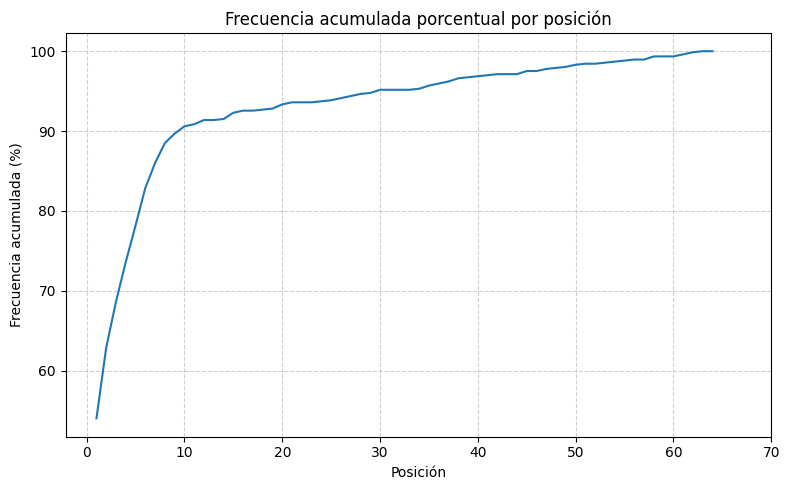

In [ ]:
acumr = accumulate_results_from_folder("BR1.out")
acumr = expand_to_x(acumr, 64)
plot_cumulative_percentage(acumr)

In [ ]:
data = parse_file("BR1.out/BR1-0.out")
generate_train_data(data, pad=64)

In [ ]:
# Ejemplo de uso
folder_path = "BR1.out"  # Carpeta que contiene los archivos
generate_data_from_folder(folder_path, pad=64)

In [ ]:
X, Y, blocks_ids = load_data_from_file("BR1.data")
print(len(X))
print(len(Y))
print(len(blocks_ids))

In [ ]:
# Ejemplo de uso
file_path = "BR1.data"  # Archivo .data de entrada
output_path = "BR1-datasets"  # Carpeta donde se guardarán los nuevos datasets
cuts = [1, 7, 64]  # Los cortes

split_and_save_datasets(file_path, cuts, output_path)

Procesando archivo: BR1.data
Dataset guardado en: BR1-datasets/1-1.data
Dataset guardado en: BR1-datasets/2-7.data
Dataset guardado en: BR1-datasets/8-64.data


In [ ]:
X, Y, blocks_ids = load_data_from_file("BR1-datasets/1-1.data")
len(X)

414

In [ ]:
gen_instances("E4v2-2.txt", n_instances=500, n_types=10, seed=42, offset=500)

In [ ]:
run_file_instances_parallel("E4v2-2.txt", exe_path="./BSG_CLP", w=8)

In [ ]:
import os
import re

def renombrar_archivos(carpeta):
    patron = re.compile(r"E4v2-2-(\d+)\.out")  # captura el número
    for archivo in os.listdir(carpeta):
        match = patron.match(archivo)
        if match:
            numero = int(match.group(1))
            nuevo_numero = numero + 500
            nuevo_nombre = f"E4v2-{nuevo_numero}.out"
            ruta_vieja = os.path.join(carpeta, archivo)
            ruta_nueva = os.path.join(carpeta, nuevo_nombre)
            os.rename(ruta_vieja, ruta_nueva)
            print(f"Renombrado: {archivo} -> {nuevo_nombre}")

# Ejemplo de uso
renombrar_archivos("E4v2-2.out")

Renombrado: E4v2-2-62.out -> E4v2-562.out
Renombrado: E4v2-2-339.out -> E4v2-839.out
Renombrado: E4v2-2-239.out -> E4v2-739.out
Renombrado: E4v2-2-312.out -> E4v2-812.out
Renombrado: E4v2-2-112.out -> E4v2-612.out
Renombrado: E4v2-2-366.out -> E4v2-866.out
Renombrado: E4v2-2-58.out -> E4v2-558.out
Renombrado: E4v2-2-153.out -> E4v2-653.out
Renombrado: E4v2-2-183.out -> E4v2-683.out
Renombrado: E4v2-2-119.out -> E4v2-619.out
Renombrado: E4v2-2-25.out -> E4v2-525.out
Renombrado: E4v2-2-372.out -> E4v2-872.out
Renombrado: E4v2-2-134.out -> E4v2-634.out
Renombrado: E4v2-2-392.out -> E4v2-892.out
Renombrado: E4v2-2-424.out -> E4v2-924.out
Renombrado: E4v2-2-380.out -> E4v2-880.out
Renombrado: E4v2-2-138.out -> E4v2-638.out
Renombrado: E4v2-2-105.out -> E4v2-605.out
Renombrado: E4v2-2-422.out -> E4v2-922.out
Renombrado: E4v2-2-452.out -> E4v2-952.out
Renombrado: E4v2-2-488.out -> E4v2-988.out
Renombrado: E4v2-2-73.out -> E4v2-573.out
Renombrado: E4v2-2-434.out -> E4v2-934.out
Renombrado: E4v

In [ ]:
!mv E4v2-2.out/* E4v2.out/

In [ ]:
!zip -r 'E4v2.out.zip' 'E4v2.out'

updating: E4v2.out/ (stored 0%)
updating: E4v2.out/E4v2-153.out (deflated 87%)
updating: E4v2.out/E4v2-144.out (deflated 87%)
updating: E4v2.out/E4v2-0.out (deflated 87%)
updating: E4v2.out/E4v2-346.out (deflated 88%)
updating: E4v2.out/E4v2-19.out (deflated 87%)
updating: E4v2.out/E4v2-277.out (deflated 89%)
updating: E4v2.out/E4v2-2.out (deflated 87%)
updating: E4v2.out/E4v2-438.out (deflated 89%)
updating: E4v2.out/E4v2-216.out (deflated 87%)
updating: E4v2.out/E4v2-145.out (deflated 87%)
updating: E4v2.out/E4v2-131.out (deflated 87%)
updating: E4v2.out/E4v2-283.out (deflated 87%)
updating: E4v2.out/E4v2-307.out (deflated 88%)
updating: E4v2.out/E4v2-116.out (deflated 86%)
updating: E4v2.out/E4v2-156.out (deflated 87%)
updating: E4v2.out/E4v2-132.out (deflated 88%)
updating: E4v2.out/E4v2-126.out (deflated 88%)
updating: E4v2.out/E4v2-118.out (deflated 88%)
updating: E4v2.out/E4v2-110.out (deflated 86%)
updating: E4v2.out/E4v2-486.out (deflated 87%)
updating: E4v2.out/E4v2-324.out (

In [ ]:
blocks_data, actions_data = parse_file("E4v2.out/E4v2-0.out")
X, Y, blocks_ids = generate_train_data(blocks_data, actions_data, pad=64)

In [ ]:
generate_data_from_folder("E4v2.out", pad=64)

Datos guardados en: E4v2.data


'E4v2.data'

In [ ]:
split_and_save_datasets("E4v2.data", [1, 64], "E4v2-datasets")

Procesando archivo: E4v2.data
Dataset guardado en: E4v2-datasets/1-1.data
Dataset guardado en: E4v2-datasets/2-64.data


In [ ]:
X, Y, blocks_ids = load_data_from_file("E4v2-datasets/1-1.data")
len(X)

11381

In [ ]:
Xf, Yf, bf = remove_elements_with_zero(X, Y, blocks_ids)
Xf, Yf, bf = remove_elements_with_less_blocks(Xf, Yf, bf, 10000)
len(Xf)

4426

In [ ]:
!zip -r E4-datasets.zip E4-datasets

  adding: E4-datasets/ (stored 0%)
  adding: E4-datasets/2-7.data (deflated 73%)
  adding: E4-datasets/8-64.data (deflated 68%)
  adding: E4-datasets/1-1.data (deflated 81%)


In [ ]:
!unzip E4-datasets.zip

Archive:  E4-datasets.zip
   creating: E4-datasets/
  inflating: E4-datasets/2-7.data    
  inflating: E4-datasets/8-64.data   
  inflating: E4-datasets/1-1.data    


In [ ]:
gen_instances("prueba.txt", n_instances=5, n_types=10, seed=1)
read_instances("prueba.txt")

In [ ]:
!unzip E4v2.out.zip

Archive:  E4v2.out.zip
replace E4v2.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: E4v2.zip                
replace E4v2.out/E4v2-153.out? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: E4v2.out/E4v2-153.out   
  inflating: E4v2.out/E4v2-144.out   
  inflating: E4v2.out/E4v2-0.out     
  inflating: E4v2.out/E4v2-346.out   
  inflating: E4v2.out/E4v2-19.out    
  inflating: E4v2.out/E4v2-277.out   
  inflating: E4v2.out/E4v2-2.out     
  inflating: E4v2.out/E4v2-438.out   
  inflating: E4v2.out/E4v2-216.out   
  inflating: E4v2.out/E4v2-145.out   
  inflating: E4v2.out/E4v2-131.out   
  inflating: E4v2.out/E4v2-283.out   
  inflating: E4v2.out/E4v2-307.out   
  inflating: E4v2.out/E4v2-116.out   
  inflating: E4v2.out/E4v2-156.out   
  inflating: E4v2.out/E4v2-132.out   
  inflating: E4v2.out/E4v2-126.out   
  inflating: E4v2.out/E4v2-118.out   
  inflating: E4v2.out/E4v2-110.out   
  inflating: E4v2.out/E4v2-486.out   
  inflating: E4v2.out/E4v2-324.out   
  inflating:

In [ ]:
%cd /content
!chmod +x BSG_CLP
!./BSG_CLP prueba.txt -i 1 -w 4 --verbose

Streaming output truncated to the last 5000 lines.
 -- box: (90,49,74) n: 15
 -- box: (50,69,54) n: 3
 -- box: (50,69,34) n: 3
block: 30666 (245,148,136)
 -- box: (90,49,74) n: 10
 -- box: (46,34,80) n: 13
block: 30667 (245,148,124)
 -- box: (90,49,74) n: 10
 -- box: (46,34,80) n: 6
 -- box: (61,34,56) n: 4
block: 30668 (245,148,133)
 -- box: (90,49,74) n: 10
 -- box: (43,58,78) n: 6
 -- box: (120,43,32) n: 2
block: 30669 (246,217,90)
 -- box: (90,49,74) n: 10
 -- box: (46,34,80) n: 2
 -- box: (50,69,54) n: 4
 -- box: (50,69,34) n: 4
block: 30670 (383,150,90)
 -- box: (90,49,74) n: 10
 -- box: (50,69,54) n: 6
 -- box: (50,69,34) n: 6
block: 30671 (363,150,90)
 -- box: (90,49,74) n: 12
 -- box: (50,69,54) n: 3
 -- box: (50,69,34) n: 3
block: 30672 (412,150,90)
 -- box: (90,49,74) n: 14
 -- box: (50,69,54) n: 3
 -- box: (50,69,34) n: 3
block: 30679 (245,74,214)
 -- box: (90,49,74) n: 10
 -- box: (39,34,65) n: 1
 -- box: (50,69,34) n: 4
block: 30685 (491,74,180)
 -- box: (90,49,74) n: 18


# Modelo y entrenamiento

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLPEncoder(nn.Module):
    def __init__(self, input_dim, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def forward(self, x):
        """
        x: [batch, src_len, input_dim]
        return: [batch, src_len, embed_dim]
        """
        return self.net(x)


class CLPTransformer(nn.Module):
    def __init__(self, src_dim, tgt_dim, num_heads, head_dim, num_layers=2, dropout_rate=0):
        super(CLPTransformer, self).__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        embed_dim = num_heads * head_dim

        # --- Encoder reemplazado por MLP ---
        self.encoder = MLPEncoder(src_dim, embed_dim)

        # --- Decoder ---
        self.decoder_input_proj = nn.Linear(tgt_dim, embed_dim)
        self.decoder_layers = nn.ModuleList([
            nn.ModuleDict({
                'self_attn': nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True),
                'cross_attn': nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True),
                'ffn': nn.Sequential(
                    nn.Linear(embed_dim, 512),
                    nn.ReLU(),
                    nn.Linear(512, embed_dim)
                ),
                'norm1': nn.LayerNorm(embed_dim),
                'norm2': nn.LayerNorm(embed_dim),
                'norm3': nn.LayerNorm(embed_dim)
            }) for _ in range(num_layers)
        ])

        # --- Output layer ---
        self.output_projection = nn.Linear(embed_dim, 1)

    def forward(self, src, tgt):
        """
        src: [batch, src_len, src_dim] -> bloques fijos
        tgt: [batch, tgt_len, tgt_dim] -> secuencia parcial de acciones
        """

        # --- Encoder con MLP ---
        memory = self.encoder(src)  # [batch, src_len, embed_dim]

        # --- Decoder ---
        tgt_proj = self.decoder_input_proj(tgt)
        for layer in self.decoder_layers:
            # self-attention en decoder
            self_attn_out, _ = layer['self_attn'](tgt_proj, tgt_proj, tgt_proj)
            tgt_proj = layer['norm1'](tgt_proj + self_attn_out)

            # cross-attention con encoder
            cross_attn_out, _ = layer['cross_attn'](tgt_proj, memory, memory)
            tgt_proj = layer['norm2'](tgt_proj + cross_attn_out)

            # feed-forward
            ffn_out = layer['ffn'](tgt_proj)
            tgt_proj = layer['norm3'](tgt_proj + ffn_out)

        # --- Salida ---
        output = self.output_projection(tgt_proj)  # [batch, tgt_len, 1]
        # Flatten
        flat_output = output.view(output.size(0), -1) # [batch, tgt_len]
        return flat_output # Retorna los logits (sin aplicar softmax)



# Hiperparámetros
src_dim = 3      # features de los bloques
tgt_dim = 13     # features de las acciones
num_heads = 4
head_dim = 32
num_layers = 2

# Crear modelo
model = CLPTransformer(
    src_dim=src_dim,
    tgt_dim=tgt_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers
)

# Datos inventados
batch_size = 2
src_len = 10000   # bloques en encoder
tgt_len = 64      # acciones factibles

src = torch.randn(batch_size, src_len, src_dim)  # [2, 10000, 13]
tgt = torch.randn(batch_size, tgt_len, tgt_dim)  # [2, 64, 7]

# Forward
output = model(src, tgt)

In [ ]:
X, Y, blocks_ids = load_data_from_file("E4v2-datasets/1-1.data")
X, Y, _ = remove_elements_with_zero(X, Y, blocks_ids)
X = torch.tensor(X[:500])
Y = torch.tensor(Y[:500])

print(X.shape, Y.shape)

torch.Size([500, 64, 4]) torch.Size([500, 64])


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, random_split

dataset = TensorDataset(X, Y)

# Dividir el dataset en entrenamiento y prueba
train_size = int(0.5 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

AttributeError: 'list' object has no attribute 'size'

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Definir el modelo, la función de pérdida y el optimizador
loss_function = torch.nn.CrossEntropyLoss()  # Pérdida sin reducción
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Ciclo de entrenamiento
epochs = 1

history = {split: {'loss': [], 'acc': []} for split in ['train', 'val']}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0; total = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # Limpia los gradientes
        outputs = model(X_batch)  # Obtenemos logits

        # Calcular la pérdida para cada elemento en el batch
        loss = loss_function(outputs, y_batch.argmax(dim=-1))

        loss.backward()  # Backward pass
        optimizer.step()  # Actualizar parámetros

        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch.argmax(dim=1)).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy = 100 * correct / total
    history['train']['loss'].append(train_loss)
    history['train']['acc'].append(train_accuracy)

    # Validación
    model.eval()
    validation_loss = 0
    correct = 0; total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)  # Obtenemos logits

            # Calcular la pérdida para cada elemento en el batch (sin reducción)
            loss = loss_function(outputs, y_batch.argmax(dim=-1))

            validation_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch.argmax(dim=1)).sum().item()

    validation_loss /= len(test_loader.dataset)
    validation_accuracy = 100 * correct / total
    history['val']['loss'].append(validation_loss)
    history['val']['acc'].append(validation_accuracy)

    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
    print(f'Epoch {epoch+1}, Val Loss: {validation_loss:.4f}, Val Accuracy: {validation_accuracy:.2f}%')

NameError: name 'train_dataset' is not defined

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from math import log
import copy

def normalize_input(X):
    # features = [V, Loss, CS, 1/n]

    # Pasar a escala logarítmica
    '''
    for input in X:
        for fvector in input:
            # Convertir Loss a (1 - Loss)
            fvector[1] = 1 - fvector[1]

            for i in range(len(fvector)):
                fvector[i] = log(fvector[i], 10) if fvector[i] > 0 else 999999
    '''

    # Escalar con StandardScaler
    # X shape: [num_ejemplos, num_acciones, 4]
    X = np.array(X, dtype=np.float32)

    # Aplano a 2D
    X_flat = X.reshape(-1, X.shape[-1])  # [num_ejemplos*num_acciones, 4]

    # Fit/transform
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flat)

    # Vuelvo a la forma original
    X = X_scaled.reshape(-1, X.shape[1], X.shape[2])
    return X

def curriculum_learning(model, datasets, epochs, weights, train_size, test_size, batch_size, learning_rate,
                        patience=5):
    """
    Entrena un modelo con curriculum learning y early stopping en función de val_loss.

    Args:
        model: Modelo de PyTorch.
        datasets: Lista de rutas a datasets.
        epochs: Lista con número de épocas por fase.
        weights: Lista con pesos de cada dataset.
        train_size: Número total de muestras de entrenamiento por fase.
        test_size: Número total de muestras de validación por fase.
        batch_size: Tamaño de batch.
        learning_rate: Tasa de aprendizaje.
        patience: Número de épocas sin mejora antes de detener.
    """
    # Cargar los datasets
    data = []
    for dataset in datasets:
        X, Y, blocks_ids = load_data_from_file(dataset)
        X, Y, blocks_ids = remove_elements_with_zero(X, Y, blocks_ids)
        X, Y, blocks_ids = remove_elements_with_less_blocks(X, Y, blocks_ids, 10000)
        X_enc, X_dec = zip(*X)
        X_dec = normalize_input(X_dec)

        X_enc = torch.tensor(X_enc, dtype=torch.float32)
        X_dec = torch.tensor(X_dec, dtype=torch.float32)
        Y = torch.tensor(Y, dtype=torch.float32)
        data.append((X_enc, X_dec, Y))

    # Inicializar el modelo, la función de pérdida y el optimizador
    loss_function = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Histórico de métricas
    history = {split: {'loss': [], 'acc': []} for split in ['train', 'val']}

    # Early stopping
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    no_improve_epochs = 0

    # Ciclo de entrenamiento por fases
    for phase_idx in range(len(datasets)):
        # Determinar la distribución de los datasets por fase
        total_weight = sum(weights[:phase_idx + 1])
        weights_normalized = [w / total_weight for w in weights[:phase_idx + 1]]

        train_loader_list, test_loader_list = [], []

        for idx, (X_enc, X_dec, Y) in enumerate(data[:phase_idx + 1]):
            weight = weights_normalized[idx]
            num_train_samples = int(weight * train_size)
            num_test_samples = int(weight * test_size)

            dataset = TensorDataset(X_enc, X_dec, Y)
            train_dataset, remaining_dataset = random_split(dataset, [num_train_samples, len(dataset) - num_train_samples])
            test_dataset, _ = random_split(remaining_dataset, [num_test_samples, len(remaining_dataset) - num_test_samples])

            train_loader_list.append(DataLoader(train_dataset, batch_size=batch_size, shuffle=True))
            test_loader_list.append(DataLoader(test_dataset, batch_size=batch_size, shuffle=False))

        # Ciclo de entrenamiento por épocas
        for epoch in range(epochs[phase_idx]):
            model.train()
            train_loss, correct, total = 0, 0, 0

            current_train_loader = []
            for loader in train_loader_list:
                current_train_loader.extend(loader)

            for X_enc_batch, X_dec_batch, y_batch in current_train_loader:
                optimizer.zero_grad()
                outputs = model(X_enc_batch, X_dec_batch)
                loss = loss_function(outputs, y_batch.argmax(dim=-1))
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * X_dec_batch.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch.argmax(dim=1)).sum().item()

            train_loss /= total
            train_accuracy = 100 * correct / total
            history['train']['loss'].append(train_loss)
            history['train']['acc'].append(train_accuracy)

            # Validación
            model.eval()
            validation_loss, correct, total = 0, 0, 0.01
            current_test_loader = []
            for loader in test_loader_list:
                current_test_loader.extend(loader)

            with torch.no_grad():
                for X_enc_batch, X_dec_batch, y_batch in current_test_loader:
                    outputs = model(X_enc_batch, X_dec_batch)
                    loss = loss_function(outputs, y_batch.argmax(dim=-1))
                    validation_loss += loss.item() * X_dec_batch.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    total += y_batch.size(0)
                    correct += (predicted == y_batch.argmax(dim=1)).sum().item()

            validation_loss /= total
            validation_accuracy = 100 * correct / total
            history['val']['loss'].append(validation_loss)
            history['val']['acc'].append(validation_accuracy)

            print(f'Epoch {epoch + 1}/{epochs[phase_idx]}, Phase {phase_idx + 1} - '
                  f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
            print(f'Epoch {epoch + 1}/{epochs[phase_idx]}, Phase {phase_idx + 1} - '
                  f'Val Loss: {validation_loss:.4f}, Val Accuracy: {validation_accuracy:.2f}%')

            # --- EARLY STOPPING SOLO EN LOSS ---
            if validation_loss < best_loss:
                best_loss = validation_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                no_improve_epochs = 0
            else:
                no_improve_epochs += 1
                if no_improve_epochs >= patience:
                    print(f"⏹ Early stopping en la epoch {epoch+1} de la fase {phase_idx+1}")
                    model.load_state_dict(best_model_wts)
                    return history, model

    # Al terminar todas las fases, restauramos el mejor modelo
    model.load_state_dict(best_model_wts)
    return history, model

In [ ]:
# Parámetros del modelo
src_dim = 3      # features de los bloques
tgt_dim = 13     # features de las acciones
num_heads = 4
head_dim = 32
num_layers = 2

# Crear modelo
model = CLPTransformer(
    src_dim=src_dim,
    tgt_dim=tgt_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers
)

In [ ]:
datasets = ["E4v2-datasets/1-1.data", "E4v2-datasets/2-64.data"]
epochs = [0, 20]
weights = [50, 50]
train_size = 3400
test_size = 600
batch_size = 32
learning_rate = 1e-4
patience=5 # early stopping

curriculum_learning(model, datasets, epochs, weights, train_size, test_size, batch_size, learning_rate, patience)

Epoch 1/20, Phase 2 - Train Loss: 2.9431, Train Accuracy: 29.03%
Epoch 1/20, Phase 2 - Val Loss: 2.4468, Val Accuracy: 40.50%
Epoch 2/20, Phase 2 - Train Loss: 2.2575, Train Accuracy: 41.68%
Epoch 2/20, Phase 2 - Val Loss: 2.3646, Val Accuracy: 41.17%


In [ ]:
import gc

del model
gc.collect()

NameError: name 'model' is not defined

In [ ]:
torch.save(model.state_dict(), 'model.pt')

In [ ]:
model = CLPModel(input_dim=input_dim, num_heads=num_heads, head_dim=head_dim, num_layers=num_layers, dropout_rate=dropout)
model.load_state_dict(torch.load('model.pt'))

<All keys matched successfully>

# Ejecutable (testing)

In [ ]:
!git clone https://github.com/rilianx/Metasolver.git

Cloning into 'Metasolver'...
remote: Enumerating objects: 60593, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 60593 (delta 186), reused 161 (delta 160), pack-reused 60363 (from 3)
Receiving objects: 100% (60593/60593), 573.42 MiB | 20.91 MiB/s, done.
Resolving deltas: 100% (8796/8796), done.
Updating files: 100% (7475/7475), done.


In [ ]:
!cd Metasolver/ && cmake .
!cd Metasolver/ && make

CMake Warning (dev) in CMakeLists.txt:
  No project() command is present.  The top-level CMakeLists.txt file must
  contain a literal, direct call to the project() command.  Add a line of
  code such as

    project(ProjectName)

  near the top of the file, but after cmake_minimum_required().

  CMake is pretending there is a "project(Project)" command on the first
  line.
This warning is for project developers.  Use -Wno-dev to suppress it.

CMake Warning (dev) in CMakeLists.txt:
  cmake_minimum_required() should be called prior to this top-level project()
  call.  Please see the cmake-commands(7) manual for usage documentation of
  both commands.
This warning is for project developers.  Use -Wno-dev to suppress it.

CMake Deprecation Warning at CMakeLists.txt:3 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requi

In [ ]:
!python -v

import _frozen_importlib # frozen
import _imp # builtin
import '_thread' # <class '_frozen_importlib.BuiltinImporter'>
import '_warnings' # <class '_frozen_importlib.BuiltinImporter'>
import '_weakref' # <class '_frozen_importlib.BuiltinImporter'>
import '_io' # <class '_frozen_importlib.BuiltinImporter'>
import 'marshal' # <class '_frozen_importlib.BuiltinImporter'>
import 'posix' # <class '_frozen_importlib.BuiltinImporter'>
import '_frozen_importlib_external' # <class '_frozen_importlib.FrozenImporter'>
# installing zipimport hook
import 'time' # <class '_frozen_importlib.BuiltinImporter'>
import 'zipimport' # <class '_frozen_importlib.FrozenImporter'>
# installed zipimport hook
# /usr/lib/python3.12/encodings/__pycache__/__init__.cpython-312.pyc matches /usr/lib/python3.12/encodings/__init__.py
# code object from '/usr/lib/python3.12/encodings/__pycache__/__init__.cpython-312.pyc'
import '_codecs' # <class '_frozen_importlib.BuiltinImporter'>
import 'codecs' # <class '_frozen_impor

In [ ]:
!chmod +x BSG_CLP
!./BSG_CLP --help

  ./BSG_CLP {OPTIONS} [instance-set]

    ********* BSG-CLP *********.

  OPTIONS:

      -h, --help                        Display this help menu
      -i[int]                           Instance
      -f[string]                        Format: (BR, BRw, 1C)
      --min_fr=[double]                 Minimum volume occupied by a block
                                        (proportion)
      -w[int]                           Beam width (nodes per level)
      --seed=[int]                      Random seed
      --alpha=[double]                  Alpha parameter
      --beta=[double]                   Beta parameter
      --gamma=[double]                  Gamma parameter
      --delta=[double]                  Delta parameter
      -p[double]                        p parameter
      --json                            json output tuple
      --verbose                         Show the actions to reach the solution
      --verbose2=[layout]               Verbose v2
      --plot                  

In [ ]:
gen_instances("prueba.txt", n_instances=5, n_types=10, seed=1)
read_instances("prueba.txt")

In [ ]:
!./BSG_CLP prueba.txt -i 1 -w 4 --verbose2=16

Streaming output truncated to the last 5000 lines.
block: 30792 (392,123,90)
 -- box: (90,49,74) n: 10
 -- box: (120,43,32) n: 6
block: 30795 (296,123,180)
 -- box: (90,49,74) n: 20
block: 30796 (296,123,124)
 -- box: (90,49,74) n: 10
 -- box: (61,34,56) n: 10
block: 30798 (298,123,124)
 -- box: (90,49,74) n: 10
 -- box: (61,34,56) n: 6
 -- box: (39,34,65) n: 6
block: 30799 (296,123,124)
 -- box: (90,49,74) n: 10
 -- box: (61,34,56) n: 8
 -- box: (39,34,65) n: 3
block: 30800 (296,123,133)
 -- box: (90,49,74) n: 10
 -- box: (120,43,32) n: 9
block: 30801 (300,192,90)
 -- box: (90,49,74) n: 10
 -- box: (50,69,54) n: 6
 -- box: (50,69,34) n: 6
block: 30806 (148,157,180)
 -- box: (90,49,74) n: 10
 -- box: (46,34,80) n: 3
 -- box: (50,69,34) n: 4
block: 30807 (191,123,180)
 -- box: (90,49,74) n: 10
 -- box: (43,58,78) n: 2
 -- box: (120,43,32) n: 3
block: 30808 (182,123,180)
 -- box: (90,49,74) n: 10
 -- box: (61,34,56) n: 6
block: 30809 (182,123,180)
 -- box: (90,49,74) n: 10
 -- box: (61,3